In [2]:
#importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.json to train.json
Saving test.json to test.json


In [4]:
train_df = pd.read_json("train.json", lines=True)

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                2400 non-null   int64  
 1   id                   2400 non-null   object 
 2   sequence             2400 non-null   object 
 3   structure            2400 non-null   object 
 4   predicted_loop_type  2400 non-null   object 
 5   signal_to_noise      2400 non-null   float64
 6   SN_filter            2400 non-null   int64  
 7   seq_length           2400 non-null   int64  
 8   seq_scored           2400 non-null   int64  
 9   reactivity_error     2400 non-null   object 
 10  deg_error_Mg_pH10    2400 non-null   object 
 11  deg_error_pH10       2400 non-null   object 
 12  deg_error_Mg_50C     2400 non-null   object 
 13  deg_error_50C        2400 non-null   object 
 14  reactivity           2400 non-null   object 
 15  deg_Mg_pH10          2400 non-null   o

In [6]:
train_df.head(1)

,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,deg_error_Mg_pH10,deg_error_pH10,deg_error_Mg_50C,deg_error_50C,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,0,id_001f94081,GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUA...,.....((((((.......)))).)).((.....((..((((((......,EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHH...,6.894,1,107,68,"[0.1359, 0.20700000000000002, 0.1633, 0.1452, ...","[0.26130000000000003, 0.38420000000000004, 0.1...","[0.2631, 0.28600000000000003, 0.0964, 0.1574, ...","[0.1501, 0.275, 0.0947, 0.18660000000000002, 0...","[0.2167, 0.34750000000000003, 0.188, 0.2124, 0...","[0.3297, 1.5693000000000001, 1.1227, 0.8686, 0...","[0.7556, 2.983, 0.2526, 1.3789, 0.637600000000...","[2.3375, 3.5060000000000002, 0.3008, 1.0108, 0...","[0.35810000000000003, 2.9683, 0.2589, 1.4552, ...","[0.6382, 3.4773, 0.9988, 1.3228, 0.78770000000..."


In [7]:
# Length of the first RNA sequence
print("Sequence Length :", len(train_df.loc[0, "sequence"]))

# Length of the first RNA structure
print("Structure Length :", len(train_df.loc[0, "structure"]))

# Length of the first loop type
print("Loop Type Length :", len(train_df.loc[0, "predicted_loop_type"]))

# Metadata
print("\nSequence Length in Metadata :", train_df.loc[0, "seq_length"])
print("Scored Positions :", train_df.loc[0, "seq_scored"])

Sequence Length : 107
Structure Length : 107
Loop Type Length : 107

Sequence Length in Metadata : 107
Scored Positions : 68


In [8]:
train_df.isnull().sum()


,0
index,0
id,0
sequence,0
structure,0
predicted_loop_type,0
signal_to_noise,0
SN_filter,0
seq_length,0
seq_scored,0
reactivity_error,0


In [9]:
train_df.describe()

,index,signal_to_noise,SN_filter,seq_length,seq_scored
count,2400.000000,2400.000000,2400.000000,2400.0,2400.0
mean,1199.500000,4.530456,0.662083,107.0,68.0
std,692.964646,2.835142,0.473099,0.0,0.0
min,0.000000,-0.103000,0.000000,107.0,68.0
25%,599.750000,2.391000,0.000000,107.0,68.0
50%,1199.500000,4.442500,1.000000,107.0,68.0
75%,1799.250000,6.294250,1.000000,107.0,68.0
max,2399.000000,17.194000,1.000000,107.0,68.0


In [11]:
print(train_df["SN_filter"].value_counts())

SN_filter
1    1589
0     811
Name: count, dtype: int64


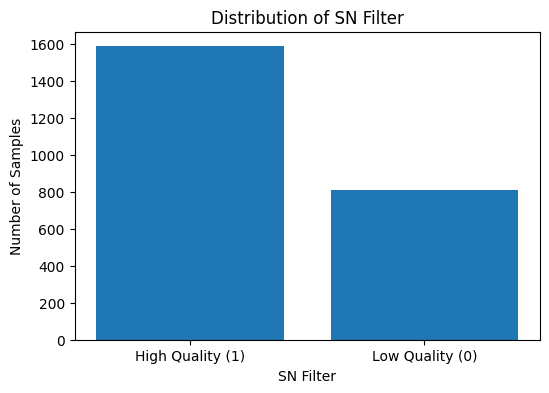

In [13]:
sn_counts = train_df["SN_filter"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["High Quality (1)","Low Quality (0)"], sn_counts.values)

plt.title("Distribution of SN Filter")
plt.xlabel("SN Filter")
plt.ylabel("Number of Samples")

plt.show()

In [14]:
# ==========================================
# Cell 9 : Inspect One RNA Sample
# ==========================================

sample = train_df.iloc[0]

print("="*80)
print("RNA SAMPLE")
print("="*80)

print("\nID:")
print(sample["id"])

print("\nSequence:")
print(sample["sequence"])

print("\nStructure:")
print(sample["structure"])

print("\nPredicted Loop Type:")
print(sample["predicted_loop_type"])

print("\nSignal to Noise:", sample["signal_to_noise"])
print("SN Filter:", sample["SN_filter"])

print("\nSequence Length:", sample["seq_length"])
print("Scored Positions:", sample["seq_scored"])

RNA SAMPLE

ID:
id_001f94081

Sequence:
GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUAACUGGAAUAACCCAUACCAGCAGUUAGAGUUCGCUCUAACAAAAGAAACAACAACAACAAC

Structure:
.....((((((.......)))).)).((.....((..((((((....))))))..)).....))....(((((((....))))))).....................

Predicted Loop Type:
EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHHHSSSSSSIISSIIIIISSXXXXSSSSSSSHHHHSSSSSSSEEEEEEEEEEEEEEEEEEEEE

Signal to Noise: 6.894
SN Filter: 1

Sequence Length: 107
Scored Positions: 68


In [15]:
# ==========================================
# Cell 10 : Find Unique Characters
# ==========================================

sequence_chars = sorted(set("".join(train_df["sequence"])))
structure_chars = sorted(set("".join(train_df["structure"])))
loop_chars = sorted(set("".join(train_df["predicted_loop_type"])))

print("Sequence Characters :", sequence_chars)
print("Structure Characters:", structure_chars)
print("Loop Type Characters:", loop_chars)

Sequence Characters : ['A', 'C', 'G', 'U']
Structure Characters: ['(', ')', '.']
Loop Type Characters: ['B', 'E', 'H', 'I', 'M', 'S', 'X']


In [16]:
# ==========================================
# Cell 11 : Create Encoding Dictionaries
# ==========================================

# RNA Sequence Encoding
sequence_map = {char: idx for idx, char in enumerate(sequence_chars)}

# Structure Encoding
structure_map = {char: idx for idx, char in enumerate(structure_chars)}

# Loop Type Encoding
loop_map = {char: idx for idx, char in enumerate(loop_chars)}

print("Sequence Encoding")
print(sequence_map)

print("\nStructure Encoding")
print(structure_map)

print("\nLoop Type Encoding")
print(loop_map)

Sequence Encoding
{'A': 0, 'C': 1, 'G': 2, 'U': 3}

Structure Encoding
{'(': 0, ')': 1, '.': 2}

Loop Type Encoding
{'B': 0, 'E': 1, 'H': 2, 'I': 3, 'M': 4, 'S': 5, 'X': 6}


In [17]:
# ==========================================
# Cell 12 : Encode One RNA Sample
# ==========================================

# First RNA sample
sample = train_df.iloc[0]

# Encode sequence
encoded_sequence = [sequence_map[char] for char in sample["sequence"]]

# Encode structure
encoded_structure = [structure_map[char] for char in sample["structure"]]

# Encode loop type
encoded_loop = [loop_map[char] for char in sample["predicted_loop_type"]]

print("First 30 Encoded Sequence Values:")
print(encoded_sequence[:30])

print("\nFirst 30 Encoded Structure Values:")
print(encoded_structure[:30])

print("\nFirst 30 Encoded Loop Type Values:")
print(encoded_loop[:30])

First 30 Encoded Sequence Values:
[2, 2, 0, 0, 0, 0, 2, 1, 3, 1, 3, 0, 0, 3, 0, 0, 1, 0, 2, 2, 0, 2, 0, 1, 3, 0, 2, 2, 0, 1]

First 30 Encoded Structure Values:
[2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 1, 2, 0, 0, 2, 2]

First 30 Encoded Loop Type Values:
[1, 1, 1, 1, 1, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 0, 5, 5, 6, 5, 5, 3, 3]


In [18]:
# ==========================================
# Cell 13 : Encode Entire Dataset
# ==========================================

# Encode all RNA sequences
X_sequence = train_df["sequence"].apply(
    lambda seq: [sequence_map[ch] for ch in seq]
)

# Encode all structures
X_structure = train_df["structure"].apply(
    lambda struct: [structure_map[ch] for ch in struct]
)

# Encode all loop types
X_loop = train_df["predicted_loop_type"].apply(
    lambda loop: [loop_map[ch] for ch in loop]
)

print("All sequences encoded successfully!")

All sequences encoded successfully!


In [19]:
# ==========================================
# Cell 14 : Convert to NumPy Arrays
# ==========================================

X_sequence = np.array(X_sequence.tolist())
X_structure = np.array(X_structure.tolist())
X_loop = np.array(X_loop.tolist())

print("Sequence Shape :", X_sequence.shape)
print("Structure Shape:", X_structure.shape)
print("Loop Shape     :", X_loop.shape)

Sequence Shape : (2400, 107)
Structure Shape: (2400, 107)
Loop Shape     : (2400, 107)


In [20]:
# ==========================================
# Cell 15 : Check Target Data Type
# ==========================================

target_columns = [
    "reactivity",
    "deg_pH10",
    "deg_Mg_pH10",
    "deg_50C",
    "deg_Mg_50C"
]

for col in target_columns:
    print(f"{col} : {type(train_df[col].iloc[0])}")

reactivity : <class 'list'>
deg_pH10 : <class 'list'>
deg_Mg_pH10 : <class 'list'>
deg_50C : <class 'list'>
deg_Mg_50C : <class 'list'>


In [21]:
print(train_df["reactivity"].iloc[0][:10])

[0.3297, 1.5693000000000001, 1.1227, 0.8686, 0.7217, 0.4384, 0.256, 0.33640000000000003, 0.21680000000000002, 0.3583]


In [22]:
# ==========================================
# Cell 16 : Convert Target Columns to NumPy Arrays
# ==========================================

import numpy as np

# Convert each target column into NumPy arrays
y_reactivity = np.array(train_df["reactivity"].tolist())

y_deg_pH10 = np.array(train_df["deg_pH10"].tolist())

y_deg_Mg_pH10 = np.array(train_df["deg_Mg_pH10"].tolist())

y_deg_50C = np.array(train_df["deg_50C"].tolist())

y_deg_Mg_50C = np.array(train_df["deg_Mg_50C"].tolist())

print("Target arrays created successfully!")

Target arrays created successfully!


In [23]:
# ==========================================
# Cell 17 : Check Target Shapes
# ==========================================

print("Reactivity Shape      :", y_reactivity.shape)
print("deg_pH10 Shape        :", y_deg_pH10.shape)
print("deg_Mg_pH10 Shape     :", y_deg_Mg_pH10.shape)
print("deg_50C Shape         :", y_deg_50C.shape)
print("deg_Mg_50C Shape      :", y_deg_Mg_50C.shape)

Reactivity Shape      : (2400, 68)
deg_pH10 Shape        : (2400, 68)
deg_Mg_pH10 Shape     : (2400, 68)
deg_50C Shape         : (2400, 68)
deg_Mg_50C Shape      : (2400, 68)


In [24]:
# ==========================================
# Cell 18 : Combine All Targets
# ==========================================

Y = np.stack([
    y_reactivity,
    y_deg_pH10,
    y_deg_Mg_pH10,
    y_deg_50C,
    y_deg_Mg_50C
], axis=-1)

print("Combined Target Shape:", Y.shape)

Combined Target Shape: (2400, 68, 5)


In [25]:
Y

array([[[ 3.29700e-01,  2.33750e+00,  7.55600e-01,  6.38200e-01,
          3.58100e-01],
        [ 1.56930e+00,  3.50600e+00,  2.98300e+00,  3.47730e+00,
          2.96830e+00],
        [ 1.12270e+00,  3.00800e-01,  2.52600e-01,  9.98800e-01,
          2.58900e-01],
        ...,
        [ 2.93700e-01,  5.14200e-01,  3.33600e-01,  3.28700e-01,
          4.81200e-01],
        [ 2.36200e-01,  7.68100e-01,  6.49100e-01,  5.30100e-01,
          7.02600e-01],
        [ 5.73100e-01,  1.17200e+00,  6.89800e-01,  8.47200e-01,
          4.25400e-01]],

       [[ 0.00000e+00,  4.94700e+00,  0.00000e+00,  7.66920e+00,
          4.85110e+00],
        [ 0.00000e+00,  4.45230e+00,  0.00000e+00,  0.00000e+00,
          4.04260e+00],
        [ 0.00000e+00,  0.00000e+00,  0.00000e+00,  1.09561e+01,
          0.00000e+00],
        ...,
        [-1.26310e+00, -2.62440e+00, -7.81700e-01, -3.19560e+00,
          1.34800e-01],
        [ 0.00000e+00,  1.06010e+00,  0.00000e+00,  0.00000e+00,
          5.27300

In [26]:
# ==========================================
# Cell 19 : Verify Target Tensor
# ==========================================

print("Shape of Y:", Y.shape)

print("\nData Type:", Y.dtype)

print("\nFirst Sample Shape:", Y[0].shape)

print("\nFirst Position Values:")
print(Y[0][0])

print("\nLast Position Values:")
print(Y[0][67])

Shape of Y: (2400, 68, 5)

Data Type: float64

First Sample Shape: (68, 5)

First Position Values:
[0.3297 2.3375 0.7556 0.6382 0.3581]

Last Position Values:
[0.5731 1.172  0.6898 0.8472 0.4254]


In [27]:
# ==========================================
# Cell 20 : Combine Input Features
# ==========================================

X = np.stack(
    [X_sequence, X_structure, X_loop],
    axis=-1
)

print("Combined Input Shape:", X.shape)

print("\nFirst RNA Shape:", X[0].shape)

print("\nFirst Position Features:")
print(X[0][0])

Combined Input Shape: (2400, 107, 3)

First RNA Shape: (107, 3)

First Position Features:
[2 2 1]


In [28]:
# ==========================================
# Cell 21 : Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Training Input Shape :", X_train.shape)
print("Validation Input Shape:", X_val.shape)

print()

print("Training Target Shape :", Y_train.shape)
print("Validation Target Shape:", Y_val.shape)

Training Input Shape : (1920, 107, 3)
Validation Input Shape: (480, 107, 3)

Training Target Shape : (1920, 68, 5)
Validation Target Shape: (480, 68, 5)


In [29]:
# ==========================================
# Cell 22 : Import Deep Learning Libraries
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    TimeDistributed,
    Reshape
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [30]:
# ==========================================
# Cell 22 : Split Each Input Separately
# ==========================================

from sklearn.model_selection import train_test_split

(
    X_seq_train,
    X_seq_val,
    X_struct_train,
    X_struct_val,
    X_loop_train,
    X_loop_val,
    Y_train,
    Y_val
) = train_test_split(
    X_sequence,
    X_structure,
    X_loop,
    Y,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Sequence Train :", X_seq_train.shape)
print("Structure Train:", X_struct_train.shape)
print("Loop Train     :", X_loop_train.shape)
print("Target Train   :", Y_train.shape)

Sequence Train : (1920, 107)
Structure Train: (1920, 107)
Loop Train     : (1920, 107)
Target Train   : (1920, 68, 5)


In [31]:
# ==========================================
# Cell 23 : Define Input Layers
# ==========================================

from tensorflow.keras.layers import Input

# Three separate inputs
sequence_input = Input(shape=(107,), name="Sequence_Input")

structure_input = Input(shape=(107,), name="Structure_Input")

loop_input = Input(shape=(107,), name="Loop_Input")

print("Input layers created successfully!")

Input layers created successfully!


In [32]:
# ==========================================
# Cell 24 : Embedding Layers
# ==========================================

from tensorflow.keras.layers import Embedding

sequence_embedding = Embedding(
    input_dim=4,
    output_dim=16,
    name="Sequence_Embedding"
)(sequence_input)

structure_embedding = Embedding(
    input_dim=3,
    output_dim=8,
    name="Structure_Embedding"
)(structure_input)

loop_embedding = Embedding(
    input_dim=7,
    output_dim=8,
    name="Loop_Embedding"
)(loop_input)

print("Embedding layers created successfully!")

Embedding layers created successfully!


In [33]:
# ==========================================
# Cell 25 : Concatenate Embeddings
# ==========================================

from tensorflow.keras.layers import Concatenate

combined = Concatenate(axis=-1)(
    [
        sequence_embedding,
        structure_embedding,
        loop_embedding
    ]
)

print("Embeddings concatenated successfully!")

Embeddings concatenated successfully!


In [34]:
# ==========================================
# Cell 26 : Bidirectional LSTM
# ==========================================

from tensorflow.keras.layers import Bidirectional, LSTM

x = Bidirectional(
    LSTM(
        128,
        return_sequences=True
    )
)(combined)

print("BiLSTM layer created!")

BiLSTM layer created!


In [35]:
# ==========================================
# Cell 27 : Dropout
# ==========================================

from tensorflow.keras.layers import Dropout

x = Dropout(0.3)(x)

print("Dropout added!")

Dropout added!


In [36]:
# ==========================================
# Cell 28 : Keep Only First 68 Positions
# ==========================================

from tensorflow.keras.layers import Lambda

# Keep only first 68 positions
x = Lambda(lambda t: t[:, :68, :], name="Select_68_Positions")(x)

print("Output Shape reduced to first 68 positions.")

Output Shape reduced to first 68 positions.


In [37]:
# ==========================================
# Cell 29 : Output Layer
# ==========================================

from tensorflow.keras.layers import TimeDistributed, Dense

output = TimeDistributed(
    Dense(5),
    name="Output_Layer"
)(x)

print("Output layer created!")

Output layer created!


In [38]:
# ==========================================
# Cell 30 : Create Model
# ==========================================

from tensorflow.keras.models import Model

model = Model(
    inputs=[
        sequence_input,
        structure_input,
        loop_input
    ],
    outputs=output
)

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Sequence_Input      │ (None, 107)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Structure_Input     │ (None, 107)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Loop_Input          │ (None, 107)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sequence_Embedding  │ (None, 107, 16)   │         64 │ Sequence_Input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Structure_Embedding │ (None, 107, 8)    │         24 │ Structure_Input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Loop_Embedding      │ (None, 107, 8)    │         56 │ Loop_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 107, 32)   │          0 │ Sequence_Embeddi… │
│ (Concatenate)       │                   │            │ Structure_Embedd… │
│                     │                   │            │ Loop_Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 107, 256)  │    164,864 │ concatenate[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 107, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Select_68_Positions │ (None, 68, 256)   │          0 │ dropout[0][0]     │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Layer        │ (None, 68, 5)     │      1,285 │ Select_68_Positi… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 166,293 (649.58 KB)

 Trainable params: 166,293 (649.58 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# ==========================================
# Cell 31 : Train the Model
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

# Stop training if validation loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x=[
        X_seq_train,
        X_struct_train,
        X_loop_train
    ],
    y=Y_train,

    validation_data=(
        [
            X_seq_val,
            X_struct_val,
            X_loop_val
        ],
        Y_val
    ),

    epochs=30,
    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 367ms/step - loss: 0.9168 - mae: 0.3610 - val_loss: 0.8693 - val_mae: 0.3261
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 384ms/step - loss: 0.8575 - mae: 0.3225 - val_loss: 0.8460 - val_mae: 0.3070
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 375ms/step - loss: 0.8449 - mae: 0.3163 - val_loss: 0.8375 - val_mae: 0.3004
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 340ms/step - loss: 0.8309 - mae: 0.3050 - val_loss: 0.8243 - val_mae: 0.2959
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 300ms/step - loss: 0.8229 - mae: 0.3026 - val_loss: 0.8207 - val_mae: 0.2873
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 309ms/step - loss: 0.8174 - mae: 0.2966 - val_loss: 0.8147 - val_mae: 0.2877
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 310ms/step - loss: 0.8130 - mae: 0.2940 - val_loss: 0.8124 - val_mae: 0.2835
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 297ms/step - loss: 0.8100 - mae: 0.2916 - val_loss: 0.8083 - val_mae: 0.2812
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 314ms/

In [40]:
# ==========================================
# Cell 32 : Evaluate Model
# ==========================================

loss, mae = model.evaluate(
    [X_seq_val, X_struct_val, X_loop_val],
    Y_val,
    verbose=1
)

print("\n========== MODEL PERFORMANCE ==========")
print(f"Validation Loss (MSE): {loss:.4f}")
print(f"Validation MAE       : {mae:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - loss: 0.7727 - mae: 0.2557

========== MODEL PERFORMANCE ==========
Validation Loss (MSE): 0.7727
Validation MAE       : 0.2557


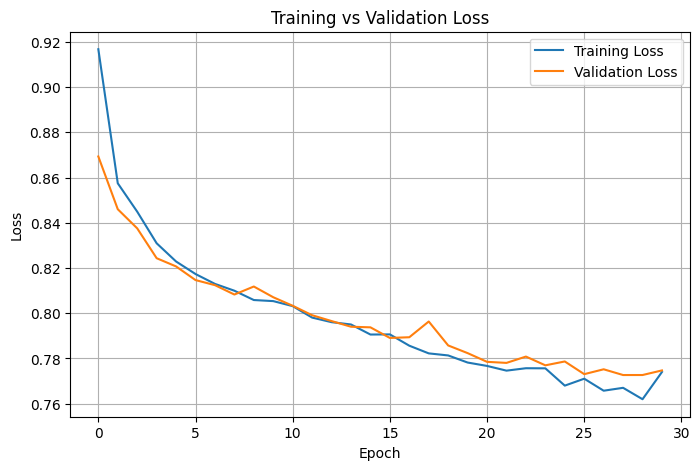

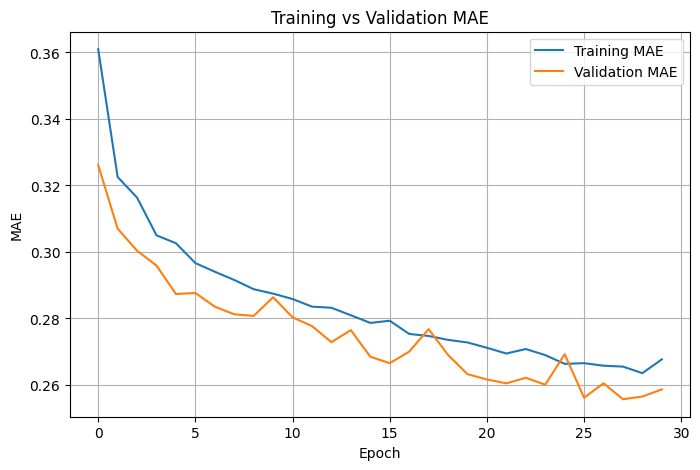

In [41]:
# ==========================================
# Cell 33 : Plot Training History
# ==========================================

import matplotlib.pyplot as plt

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# MAE Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
# ==========================================
# Cell 34 : Predict on Validation Set
# ==========================================

Y_pred = model.predict(
    [X_seq_val, X_struct_val, X_loop_val]
)

print("Prediction Shape :", Y_pred.shape)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step
Prediction Shape : (480, 68, 5)


In [43]:
# ==========================================
# Cell 35 : Compare Predictions
# ==========================================

sample = 0      # first RNA molecule
position = 0    # first nucleotide

targets = [
    "Reactivity",
    "deg_pH10",
    "deg_Mg_pH10",
    "deg_50C",
    "deg_Mg_50C"
]

print("="*50)
print("Actual vs Predicted")
print("="*50)

for i in range(5):
    print(f"{targets[i]:15s} "
          f"Actual = {Y_val[sample, position, i]:.4f}    "
          f"Predicted = {Y_pred[sample, position, i]:.4f}")

Actual vs Predicted
Reactivity      Actual = 0.4917    Predicted = 0.4633
deg_pH10        Actual = 3.4162    Predicted = 1.8892
deg_Mg_pH10     Actual = 0.5106    Predicted = 0.6038
deg_50C         Actual = 0.6859    Predicted = 0.7022
deg_Mg_50C      Actual = 0.3853    Predicted = 0.5355


In [44]:
# ==========================================
# Cell 36 : RMSE
# ==========================================

import numpy as np
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(
    Y_val.reshape(-1,5),
    Y_pred.reshape(-1,5)
))

print("RMSE :", rmse)

RMSE : 0.879024359134193


In [45]:
# ==========================================
# Cell 37 : Save Model
# ==========================================

model.save("covid_mrna_degradation_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [46]:
from google.colab import files

files.download("covid_mrna_degradation_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>